In [1]:
import scvi
import scanpy as sc
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import os


/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
"""
scArches skin

We recommend this method for assessing differential abundance (low resource).

For optimal cell annotations, we found the resource-high notebook generated better results.

"""

'\nscArches skin\n\nWe recommend this method for assessing differential abundance (low resource).\n\nFor optimal cell annotations, we found the resource-high notebook generated better results.\n\n'

# Load model

In [4]:
MODEL_PATH = '/nfs/team298/ls34/adult_skin/final_models/scVI_adultSkin_scrnaonly/'
MODEL_NAME = "scviSKIN_scrnaonly"
MODEL_PATH


'/nfs/team298/ls34/adult_skin/final_models/scVI_adultSkin_scrnaonly/'

In [5]:
"""
where to save output
"""
SAVE_OUTPUT = '/nfs/team298/ls34/new_disease_atlas/milopy_final/'
DATASET="TUTORIAL_scrna"

In [6]:
"""
LOAD YOUR DATA
"""
adata_tomap_path = '/lustre/scratch126/cellgen/haniffa/ls34/tmp/adata_skin_prepublication_r.h5ad'
target_adata=sc.read_h5ad(adata_tomap_path)


In [7]:
"""
SET SAMPLE ID COLUMN
"""
target_adata.obs["sample_id"]=target_adata.obs["orig.ident"]

In [8]:
vae_q = scvi.model.SCVI.load_query_data(
             target_adata,
             MODEL_PATH,
             inplace_subset_query_vars=True)

INFO     File /nfs/team298/ls34/adult_skin/final_models/scVI_adultSkin_scrnaonly/model.pt already downloaded       


/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/scvi/data/fields/_base_field.py:64: UserWarning: adata.X does not contain unnormalized count data. Are you sure this is what you want?
  self.validate_field(adata)


In [9]:
MAX_EPOCHS=50
neighbor=20
MIN_UMAP_DISTANCE=0.1

In [10]:
vae_q.train(max_epochs=MAX_EPOCHS, 
            early_stopping_patience=5,
            plan_kwargs=dict(weight_decay=0.0))# use_gpu='cuda')


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-SXM4-80GB MIG 1c.7g.80gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-GPU-fc991236-9668-7a85-1c2c-063ac7193c1c/0/0]
/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 1/50:   0%|          | 0/50 [00:00<?, ?it/s]

/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/scvi/module/_vae.py:458: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)
/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/scvi/module/_vae.py:458: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)


Epoch 2/50:   2%|▏         | 1/50 [00:17<14:37, 17.91s/it, v_num=1, train_loss_step=2.03e+3, train_loss_epoch=1.96e+3]

/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/scvi/module/_vae.py:458: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)
/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/scvi/module/_vae.py:458: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)


...

Epoch 50/50:  98%|█████████▊| 49/50 [13:56<00:16, 16.87s/it, v_num=1, train_loss_step=1.92e+3, train_loss_epoch=1.95e+3]

/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/scvi/module/_vae.py:458: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)
/software/cellgen/team298/ls34/scpoli/lib/python3.11/site-packages/scvi/module/_vae.py:458: UserWarning: The value argument must be within the support of the distribution
  reconst_loss = -generative_outputs["px"].log_prob(x).sum(-1)


Epoch 50/50: 100%|██████████| 50/50 [14:13<00:00, 16.82s/it, v_num=1, train_loss_step=1.9e+3, train_loss_epoch=1.95e+3] 

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 50/50: 100%|██████████| 50/50 [14:13<00:00, 17.06s/it, v_num=1, train_loss_step=1.9e+3, train_loss_epoch=1.95e+3]


In [11]:
print("trained")
vae_q.save(SAVE_OUTPUT + f'{MODEL_NAME}_{DATASET}',
                   save_anndata=True, overwrite=True)

trained


In [12]:
latent = vae_q.get_latent_representation() 
target_adata=sc.read_h5ad(adata_tomap_path)



In [13]:
target_adata.obsm["X_scarches"] = latent


In [14]:
neighbor_id = "neighbor_"+str(neighbor)   
sc.pp.neighbors(target_adata, use_rep = 'X_scarches', metric = "euclidean", n_neighbors=neighbor)
print("neighbours done")

sc.tl.umap(target_adata, min_dist=MIN_UMAP_DISTANCE) 
print(f"UMAP done. Min dist {MIN_UMAP_DISTANCE}")


neighbours done
UMAP done. Min dist 0.1


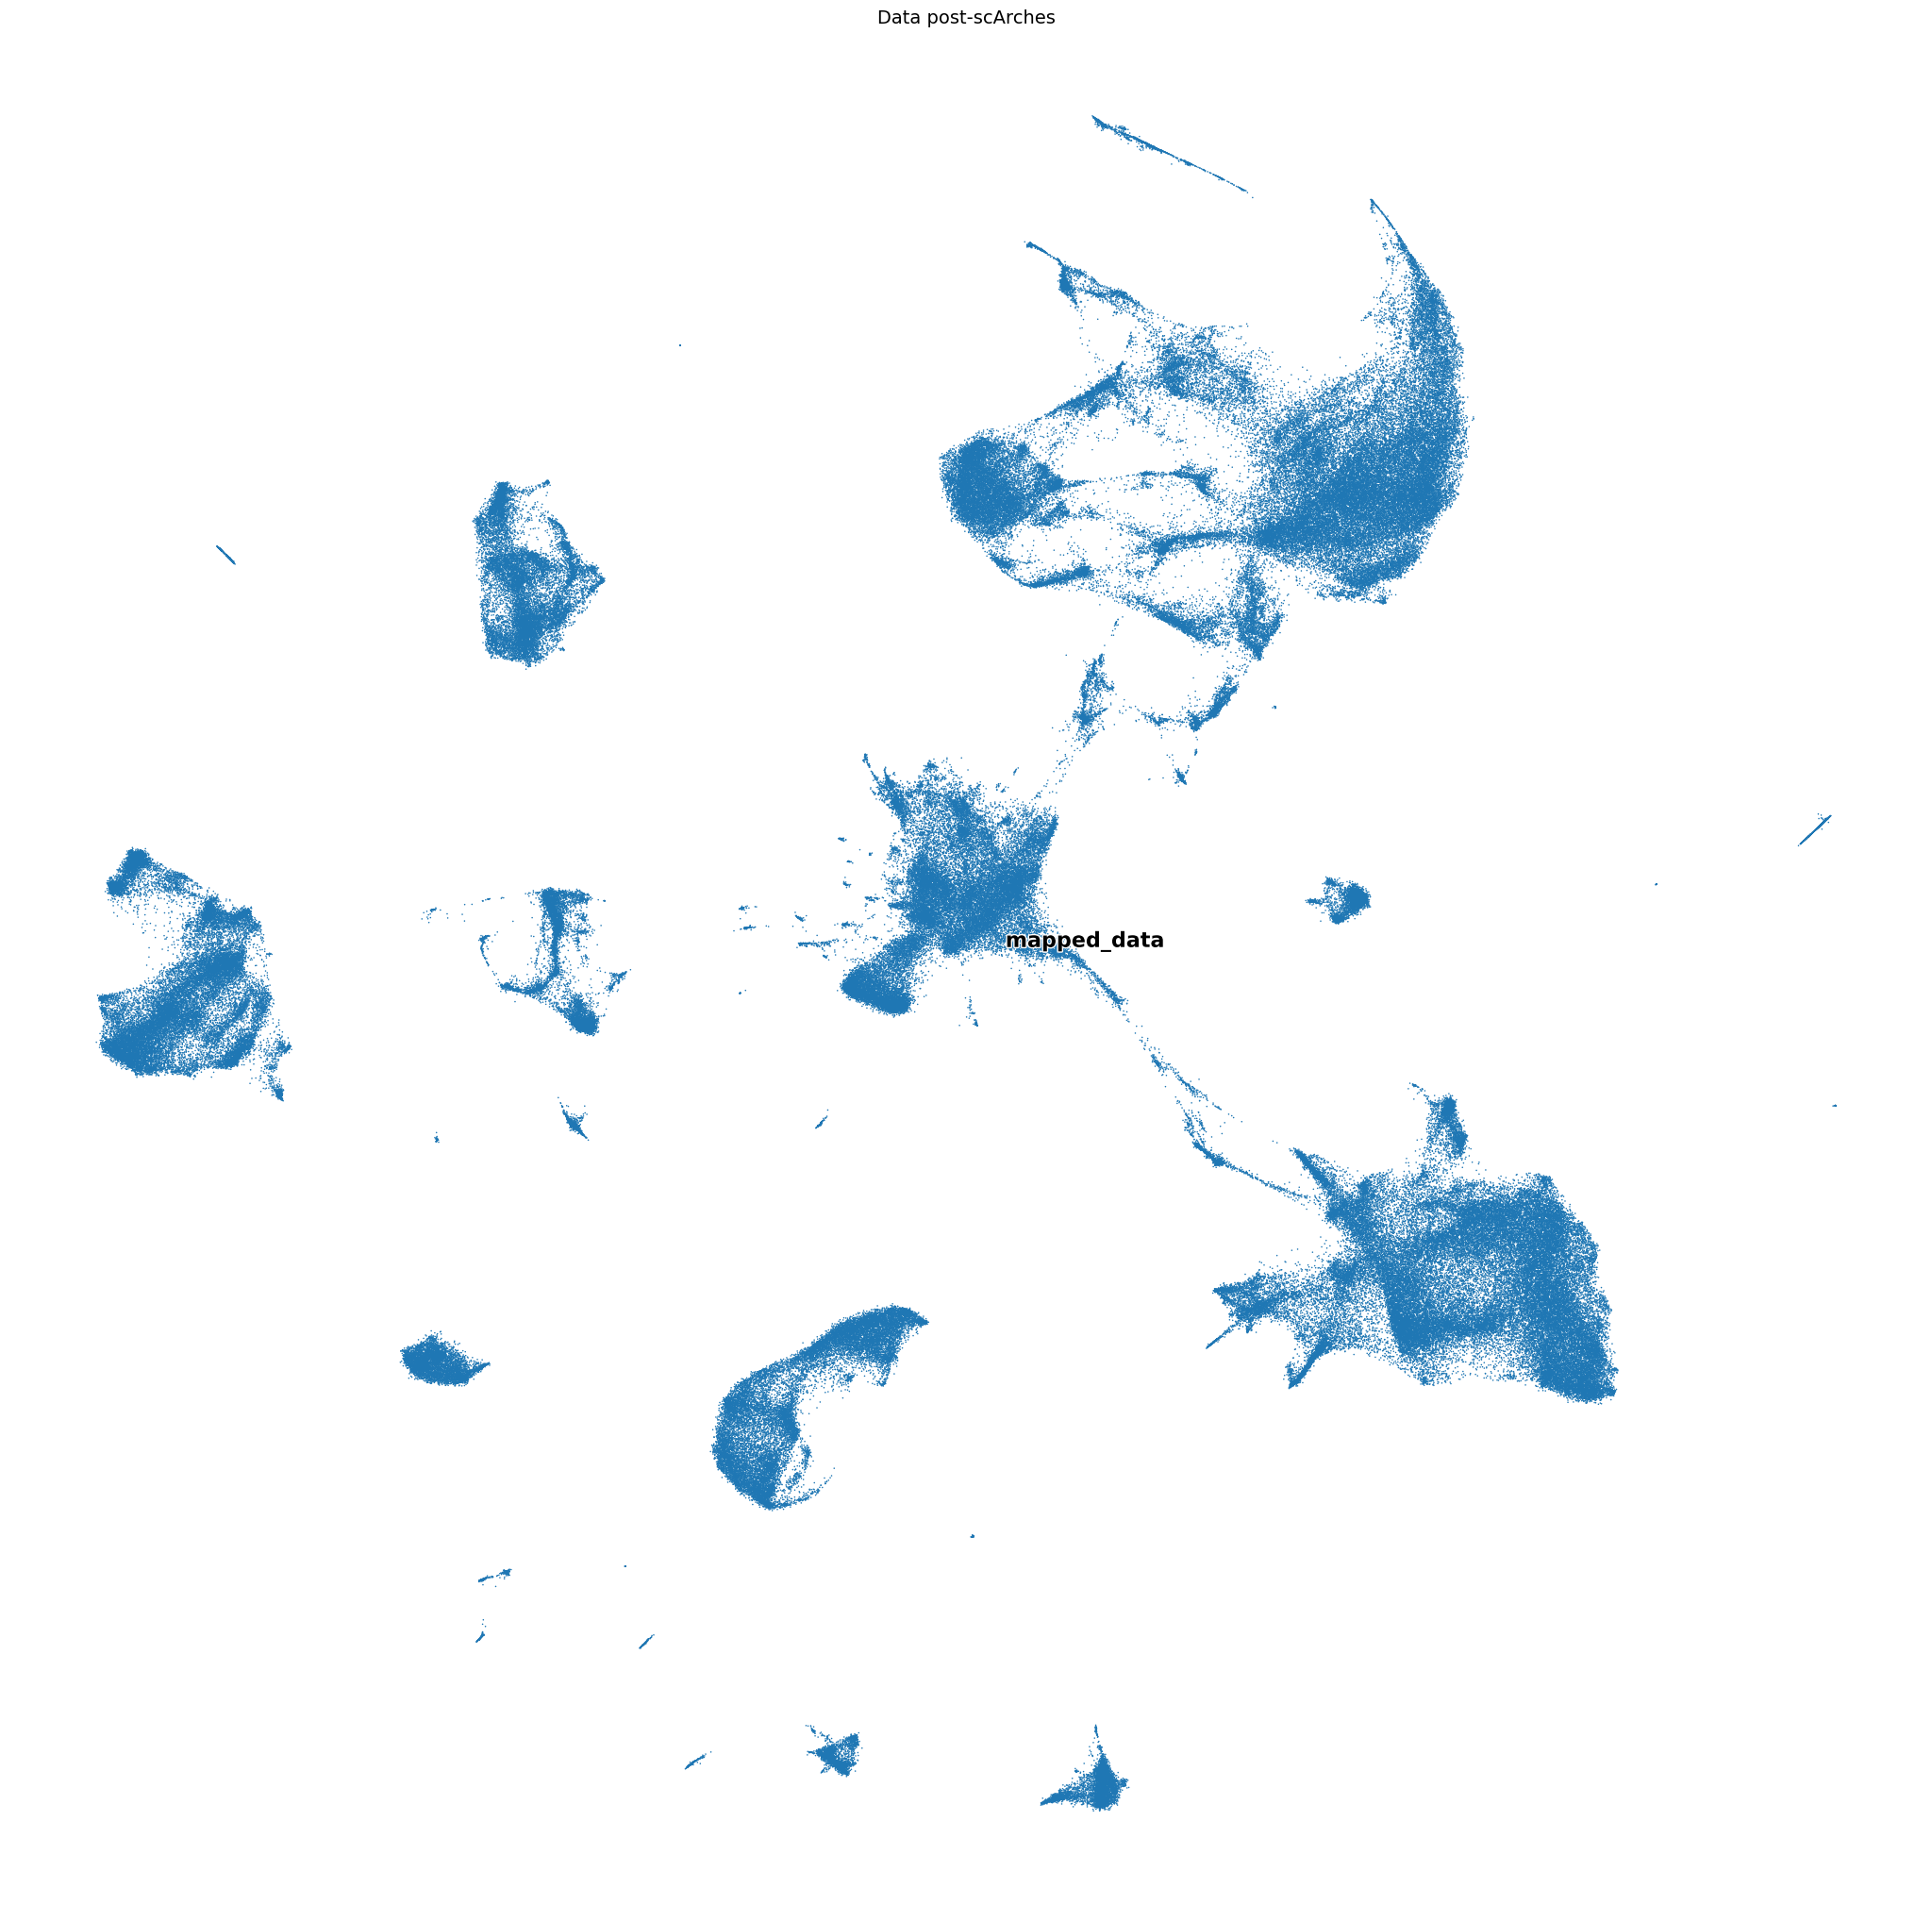

In [15]:
"""
Show how new data maps to atlas. Note that if no QC has been performed, a low QC cluster often forms (but in this dataset, QC had already been performed)
"""
target_adata.obs["forplot"]="mapped_data"
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(26,26))

sc.pl.umap(
    target_adata,
    color=[
        'forplot',  
    ],
    legend_loc="on data",
    s=5, 
    legend_fontoutline=2,
    legend_fontsize=16,
    title="Data post-scArches"
)

In [16]:
SAVE_PATH = SAVE_OUTPUT + f'{MODEL_NAME}_{DATASET}/adata_processed_scarchesskin.h5ad'
target_adata.write(SAVE_PATH)
print("Saved to: ", SAVE_PATH )

Saved to:  /nfs/team298/ls34/new_disease_atlas/milopy_final/scviSKIN_scrnaonly_TUTORIAL_scrna/adata_processed_scarchesskin.h5ad


# Let's see how the annotations look from the high-res tutorial

In [17]:
# import scanpy as sc
# target_adata=sc.read_h5ad('/nfs/team298/ls34/new_disease_atlas/milopy_final/scviSKIN_TUTORIAL/adata_processed_scarchesskin.h5ad')


In [18]:
!wget "https://raw.githubusercontent.com/haniffalab/spatial_skin_atlas/main/misc/color_for_adult_skin2.pkl" \
     -O color_for_adult_skin2.pkl

import pickle
file_path = "./color_for_adult_skin2.pkl"

with open(file_path, "rb") as f:
    colors = pickle.load(f)
colors= colors | {'New/unlabelled/excluded': "#C8C8C8"}
print(f"Loaded {len(colors)} colour entries")

/software/isg/languages/Python/Python-3.11.4/lib/python3.11/pty.py:89: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


--2025-11-30 16:18:49--  https://raw.githubusercontent.com/haniffalab/spatial_skin_atlas/main/misc/color_for_adult_skin2.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4369 (4.3K) [application/octet-stream]
Saving to: ‘color_for_adult_skin2.pkl’

color_for_adult_ski 100%[===================>]   4.27K  --.-KB/s    in 0s      

2025-11-30 16:18:49 (55.8 MB/s) - ‘color_for_adult_skin2.pkl’ saved [4369/4369]

Loaded 195 colour entries


In [19]:
import pickle

path = "/nfs/team298/ls34/dicts/tutorial_scanvi_predictions.pkl"

with open(path, "rb") as f:
    scanvi_predictions_dict = pickle.load(f)

target_adata.obs["resourcehi_predictions"]=target_adata.obs.index.map(scanvi_predictions_dict)
target_adata.obs["resourcehi_predictions"].value_counts()

resourcehi_predictions
KC3                 61958
F1: Superficial     23444
F2: Universal       18649
KC1                 18616
Pericyte1           11147
                    ...  
ILC_Prolif              4
Satellite cell          3
ILC3_CCL1+PTGDS+        3
Cartilage               2
Eosinophil              1
Name: count, Length: 102, dtype: int64

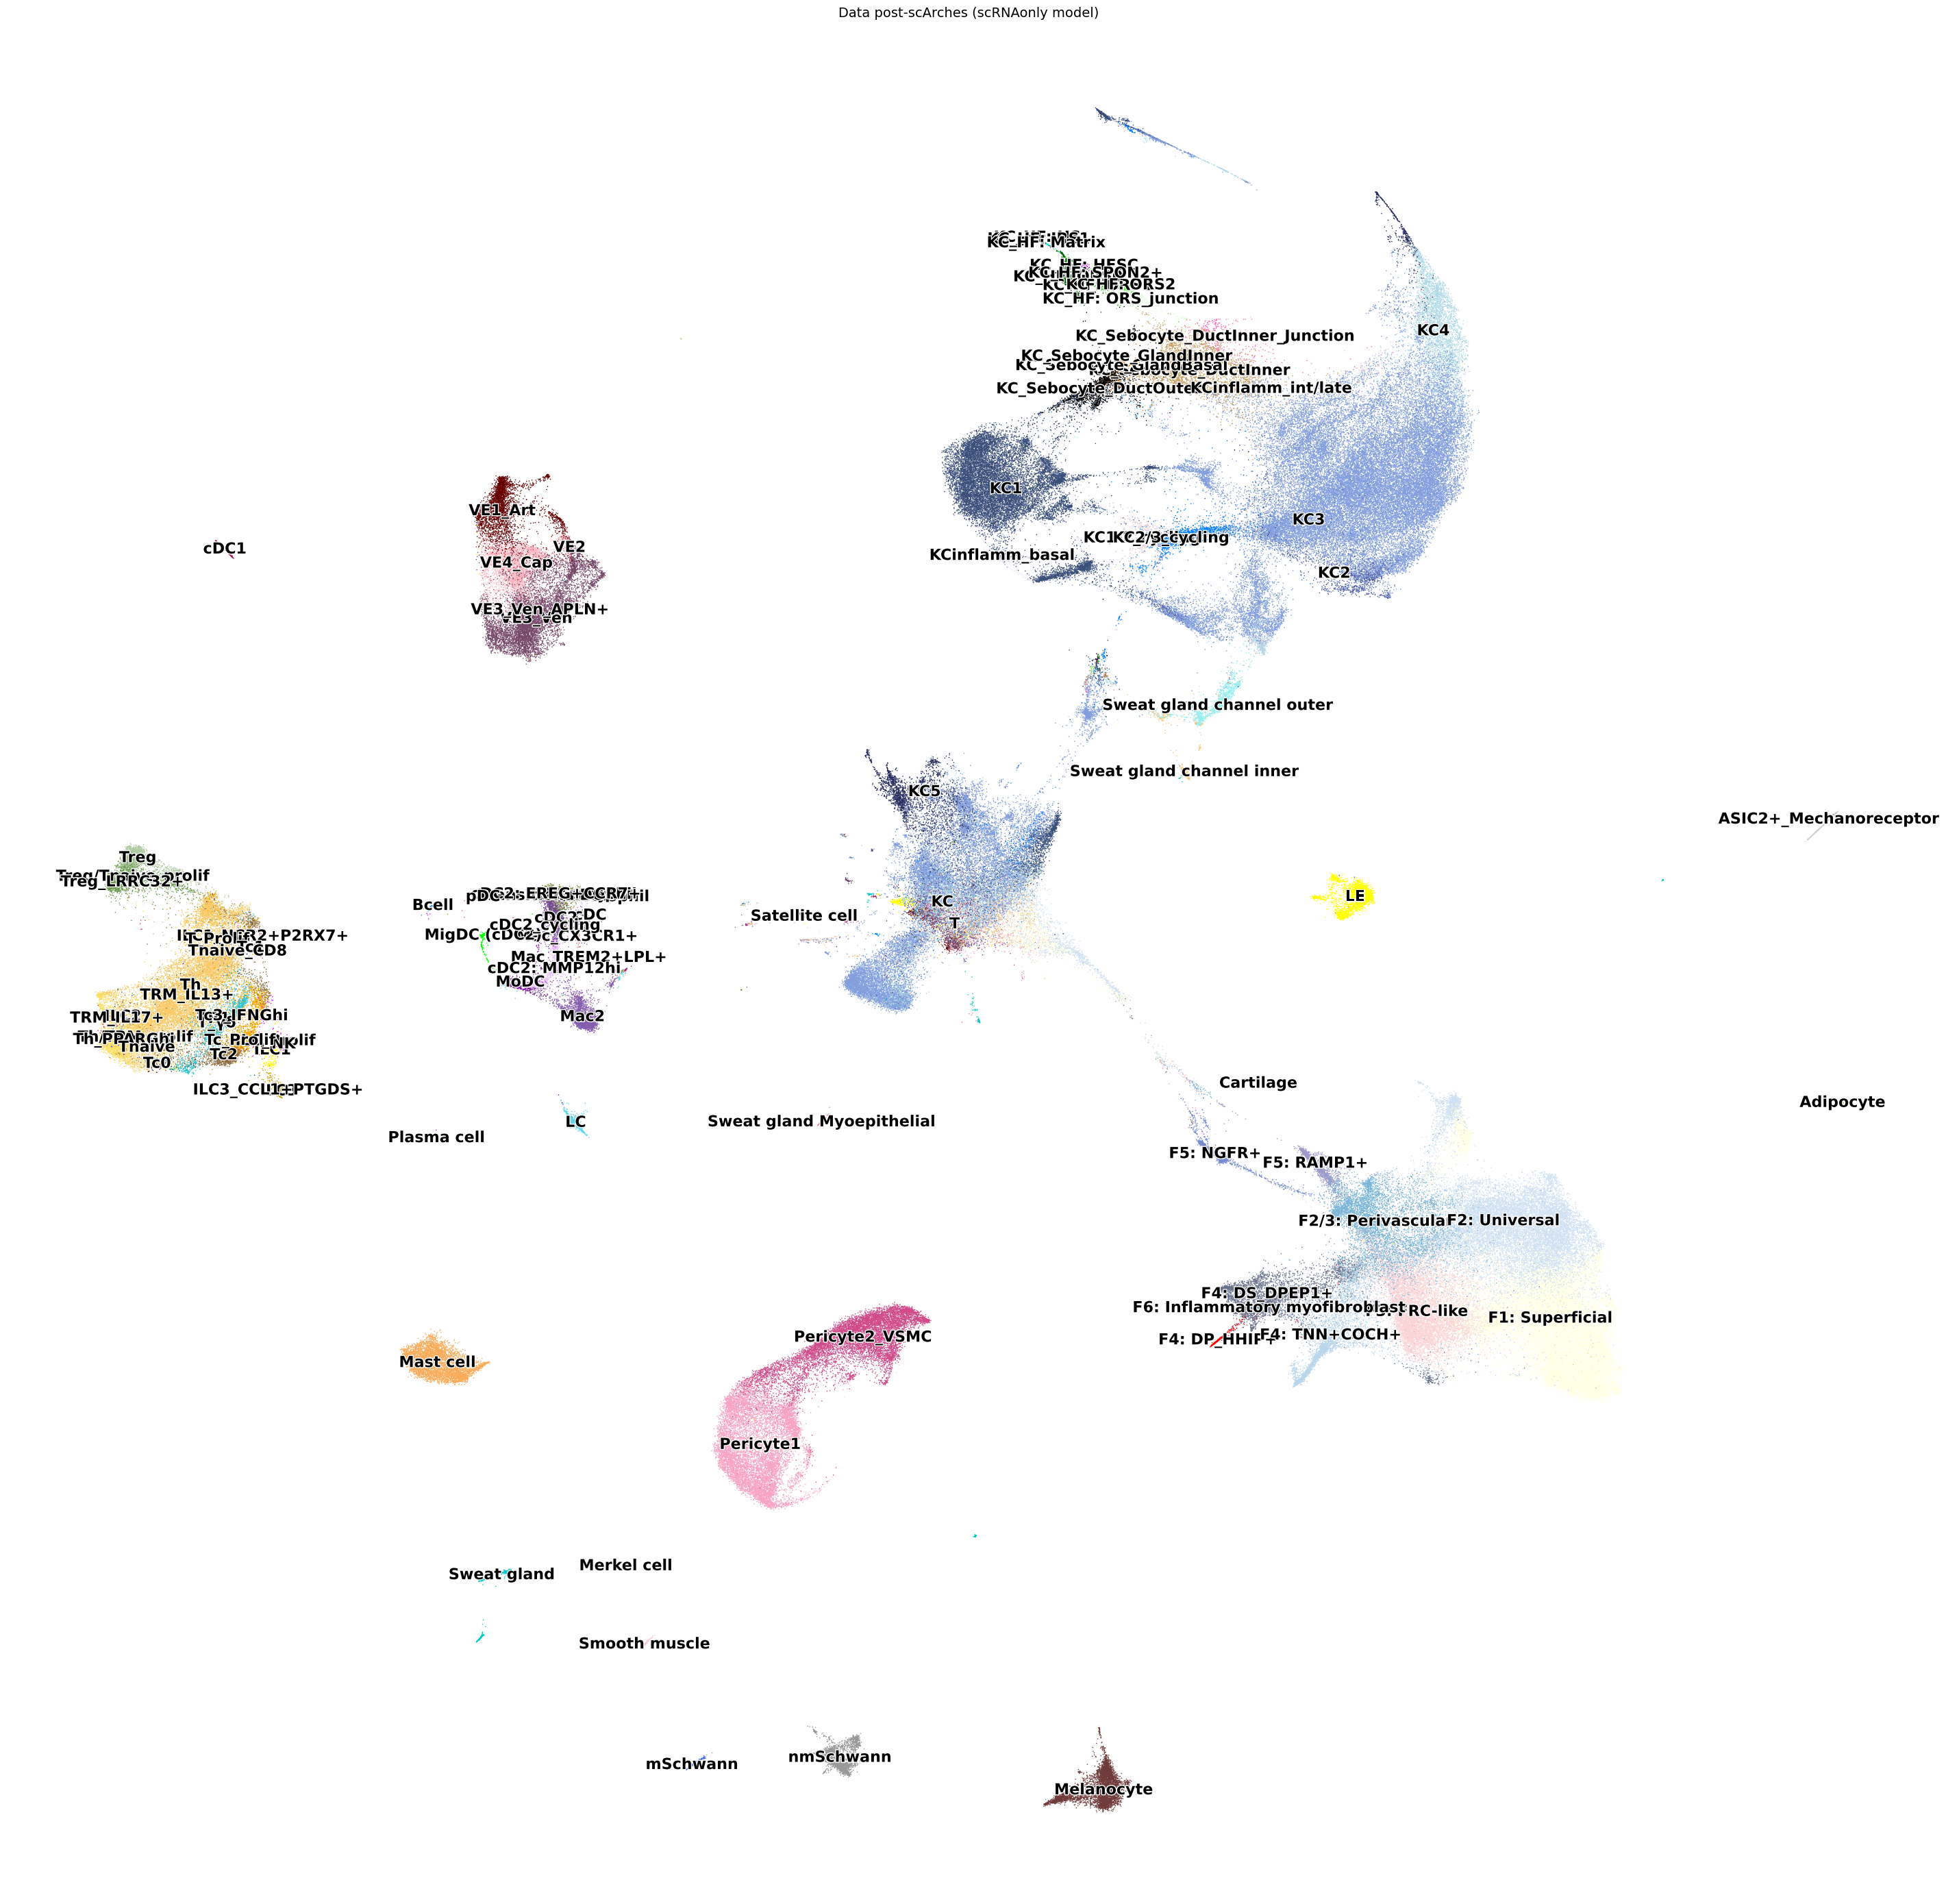

In [23]:
"""
not too bad at all (given it is very quick)!

Central population likely represents a low quality population to exclude 
"""
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(36,36))

sc.pl.umap(
    target_adata,
    color=[
        'resourcehi_predictions',  
    ],
    legend_loc="on data",
    s=5, 
    legend_fontoutline=2,
    legend_fontsize=16,
    title="Data post-scArches (scRNAonly model)",
    palette=colors,
)

# versions

In [21]:
sc.logging.print_versions()




-----
anndata     0.10.7
scanpy      1.10.1
-----
PIL                 10.3.0
absl                NA
asttokens           NA
attr                23.2.0
chex                0.1.86
comm                0.2.2
contextlib2         NA
cycler              0.12.1
cython_runtime      NA
dateutil            2.9.0.post0
debugpy             1.8.1
decorator           5.1.1
docrep              0.3.2
etils               1.9.1
executing           2.0.1
filelock            3.14.0
flax                0.8.4
fsspec              2024.6.0
h5py                3.11.0
igraph              0.11.8
ipykernel           6.29.4
jax                 0.4.35
jax_cuda12_plugin   NA
jax_plugins         NA
jaxlib              0.4.34
jedi                0.19.1
joblib              1.4.2
kiwisolver          1.4.5
legacy_api_wrap     NA
leidenalg           0.10.2
lightning           2.1.4
lightning_utilities 0.11.2
llvmlite            0.43.0
matplotlib          3.9.0
matplotlib_inline   0.1.7
ml_collections      NA
ml_dtypes      